In [ ]:
from google.colab import files
uploaded = files.upload()

Saving airlines_reviews.csv to airlines_reviews.csv


In [ ]:
import pandas as pd
import io
# Get the actual filename from the uploaded dictionary
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))
print(df.head())

                                  Title              Name Review Date  \
0                    Flight was amazing  Alison Soetantyo  2024-03-01   
1  seats on this aircraft are dreadful      Robert Watson  2024-02-21   
2          Food was plentiful and tasty             S Han  2024-02-20   
3          “how much food was available          D Laynes  2024-02-19   
4       “service was consistently good”         A Othman   2024-02-19   

              Airline Verified  \
0  Singapore Airlines     True   
1  Singapore Airlines     True   
2  Singapore Airlines     True   
3  Singapore Airlines     True   
4  Singapore Airlines     True   

                                             Reviews Type of Traveller  \
0    Flight was amazing. The crew onboard this fl...      Solo Leisure   
1    Booking an emergency exit seat still meant h...      Solo Leisure   
2    Excellent performance on all fronts. I would...    Family Leisure   
3   Pretty comfortable flight considering I was f...      So

In [ ]:
!pip install transformers imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import RandomOverSampler


In [ ]:
from transformers import pipeline

# Load pretrained 3-class sentiment model
sentiment_model = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment",
    tokenizer="cardiffnlp/twitter-roberta-base-sentiment"
)

# Map labels to human-readable
label_map = {"LABEL_0": "Negative", "LABEL_1": "Neutral", "LABEL_2": "Positive"}

def text_to_sentiment(text):
    try:
        result = sentiment_model(str(text)[:512])[0]  # cut long reviews
        return label_map[result["label"]]
    except:
        return "Neutral"

df["final_sentiment"] = df["Reviews"].astype(str).apply(text_to_sentiment)

print(df["final_sentiment"].value_counts())


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Device set to use cuda:0
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


final_sentiment
Positive    3712
Negative    3673
Neutral      715
Name: count, dtype: int64


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from imblearn.over_sampling import RandomOverSampler

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.models import Sequential
from tensorflow.keras.initializers import Constant
from tensorflow.keras.utils import to_categorical

In [ ]:
label_encoder = LabelEncoder()
df["label_id"] = label_encoder.fit_transform(df["final_sentiment"])
class_names = label_encoder.classes_
print("Classes:", class_names)

X = df["Reviews"].astype(str).values
y = df["label_id"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Classes: ['Negative' 'Neutral' 'Positive']


In [ ]:
MAX_NUM_WORDS = 20000
MAX_SEQ_LEN = 200  # increased length to capture more context

tokenizer = Tokenizer(num_words=MAX_NUM_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQ_LEN, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_SEQ_LEN, padding="post", truncating="post")

In [ ]:
ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X_train_pad, y_train)

print("Before balancing:", np.bincount(y_train))
print("After balancing:", np.bincount(y_res))

Before balancing: [2938  572 2970]
After balancing: [2970 2970 2970]


In [ ]:
embedding_index = {}
with open("glove.6B.100d.txt", encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embedding_index[word] = vector

embedding_dim = 100
word_index = tokenizer.word_index
num_words = min(MAX_NUM_WORDS, len(word_index)) + 1

embedding_matrix = np.zeros((num_words, embedding_dim))
for word, i in word_index.items():
    if i < num_words:
        vector = embedding_index.get(word)
        if vector is not None:
            embedding_matrix[i] = vector

print("✅ GloVe embedding matrix shape:", embedding_matrix.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'glove.6B.100d.txt'

In [ ]:
# 1. Download and unzip GloVe (make sure it runs before loading embeddings)
!wget -q http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip

# 2. Load embeddings into dictionary
embedding_index = {}
with open("glove.6B.100d.txt", encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embedding_index[word] = vector

print("✅ Loaded GloVe vectors:", len(embedding_index))


✅ Loaded GloVe vectors: 400000


In [ ]:
embedding_dim = 100
word_index = tokenizer.word_index
num_words = min(MAX_NUM_WORDS, len(word_index)) + 1

embedding_matrix = np.zeros((num_words, embedding_dim))
for word, i in word_index.items():
    if i < num_words:
        vector = embedding_index.get(word)
        if vector is not None:
            embedding_matrix[i] = vector

print("✅ GloVe embedding matrix shape:", embedding_matrix.shape)


✅ GloVe embedding matrix shape: (19393, 100)


In [ ]:
ros = RandomOverSampler(random_state=42)
# RandomOverSampler expects 2D X; that's fine since X_train_pad is 2D (n_samples x seq_len)
X_res, y_res = ros.fit_resample(X_train_pad, y_train)
print("Before balancing:", np.bincount(y_train))
print("After balancing:", np.bincount(y_res))
print("Resampled shapes:", X_res.shape, y_res.shape)

# Convert resampled X_res (numpy 2D) to same dtype
X_res = X_res.astype(np.int32)

# One-hot labels for focal loss training
num_classes = len(class_names)
y_res_cat = to_categorical(y_res, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

Before balancing: [2938  572 2970]
After balancing: [2970 2970 2970]
Resampled shapes: (8910, 200) (8910,)


In [ ]:
from tensorflow.keras import backend as K

def categorical_focal_loss(alpha=0.25, gamma=2.0):
    alpha = tf.constant(alpha, dtype=tf.float32)
    gamma = tf.constant(gamma, dtype=tf.float32)

    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, K.epsilon(), 1.0 - K.epsilon())
        cross_ent = - y_true * tf.math.log(y_pred)
        weight = alpha * tf.math.pow(1.0 - y_pred, gamma)
        loss = tf.reduce_sum(weight * cross_ent, axis=-1)
        return loss
    return loss

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, GRU, Dense, Dropout
from tensorflow.keras.initializers import Constant
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Embedding(input_dim=num_words,
              output_dim=embedding_dim,
              embeddings_initializer=Constant(embedding_matrix),
              input_length=MAX_SEQ_LEN,
              trainable=False),
    Bidirectional(GRU(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.2)),
    Bidirectional(GRU(64, return_sequences=False, dropout=0.3, recurrent_dropout=0.2)),
    Dense(64, activation="relu"),
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

model.compile(
    loss=categorical_focal_loss(alpha=0.25, gamma=2.0),
    optimizer=Adam(learning_rate=1e-3),
    metrics=["accuracy"]
)

model.build(input_shape=(None, MAX_SEQ_LEN))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 100)       │     1,939,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 200, 256)       │       176,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       123,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,248,039 (8.58 MB)

 Trainable params: 308,739 (1.18 MB)

 Non-trainable params: 1,939,300 (7.40 MB)

In [ ]:
EPOCHS = 10
BATCH = 64

history = model.fit(
    X_res, y_res_cat,
    validation_data=(X_test_pad, y_test_cat),
    epochs=EPOCHS,
    batch_size=BATCH,
    verbose=1
)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 323s 2s/step - accuracy: 0.3904 - loss: 0.1227 - val_accuracy: 0.5333 - val_loss: 0.1096
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 308s 2s/step - accuracy: 0.5233 - loss: 0.1076 - val_accuracy: 0.6414 - val_loss: 0.0722
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 329s 2s/step - accuracy: 0.6182 - loss: 0.0864 - val_accuracy: 0.6167 - val_loss: 0.0769
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 305s 2s/step - accuracy: 0.6471 - loss: 0.0771 - val_accuracy: 0.7086 - val_loss: 0.0625
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 302s 2s/step - accuracy: 0.6866 - loss: 0.0686 - val_accuracy: 0.7506 - val_loss: 0.0613
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 334s 2s/step - accuracy: 0.6831 - loss: 0.0657 - val_accuracy: 0.7216 - val_loss: 0.0564
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 313s 2s/step - accuracy: 0.7230 - loss: 0.0606 - val_accuracy: 0.7778 - val_loss: 0.0524
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 316s 2s/step - accuracy: 0.7451 - loss: 0.0549 - val_accu

In [ ]:
y_pred_probs = model.predict(X_test_pad, batch_size=64)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nClassification report (test set):")
print(classification_report(y_test, y_pred, target_names=class_names))

26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 428ms/step

Classification report (test set):
              precision    recall  f1-score   support

    Negative       0.92      0.75      0.83       735
     Neutral       0.22      0.47      0.30       143
    Positive       0.89      0.87      0.88       742

    accuracy                           0.78      1620
   macro avg       0.68      0.70      0.67      1620
weighted avg       0.85      0.78      0.80      1620



In [ ]:
##########################SBERT + BiGRU + Attention + Focal Loss

In [ ]:
!pip install -q sentence-transformers tensorflow==2.15 scikit-learn

import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers, models, optimizers, backend as K
from tensorflow.keras.callbacks import EarlyStopping
from sentence_transformers import SentenceTransformer
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf

ERROR: Could not find a version that satisfies the requirement tensorflow==2.15 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0)
ERROR: No matching distribution found for tensorflow==2.15


In [ ]:
le = LabelEncoder()
df["label_id"] = le.fit_transform(df["final_sentiment"])
class_names = le.classes_.tolist()
print("Class mapping:", dict(zip(class_names, le.transform(class_names))))

Class mapping: {'Negative': np.int64(0), 'Neutral': np.int64(1), 'Positive': np.int64(2)}


In [ ]:
# ============================================================
X = df["Reviews"].astype(str).values
y = df["label_id"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# STEP 5: ENCODE REVIEWS USING SBERT
# ============================================================
sbert = SentenceTransformer("all-MiniLM-L6-v2")

print("Encoding text with SBERT... This may take a few minutes.")
X_train_emb = sbert.encode(X_train, convert_to_numpy=True, show_progress_bar=True)
X_test_emb = sbert.encode(X_test, convert_to_numpy=True, show_progress_bar=True)

print("✅ SBERT embeddings:", X_train_emb.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding text with SBERT... This may take a few minutes.


Batches:   0%|          | 0/203 [00:00<?, ?it/s]

Batches:   0%|          | 0/51 [00:00<?, ?it/s]

✅ SBERT embeddings: (6480, 384)


In [ ]:
# STEP 6: COMPUTE CLASS WEIGHTS
# ============================================================
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))
print("Class Weights:", class_weights)

Class Weights: {np.int64(0): np.float64(0.7354443309499489), np.int64(1): np.float64(3.769633507853403), np.int64(2): np.float64(0.7272727272727273)}


In [ ]:
# ============================================================
def focal_loss(gamma=2., alpha=.25):
    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        eps = K.epsilon()
        y_pred = K.clip(y_pred, eps, 1. - eps)
        cross_entropy = -y_true * K.log(y_pred)
        weight = alpha * K.pow(1 - y_pred, gamma)
        loss = weight * cross_entropy
        return K.sum(loss, axis=1)
    return focal_loss_fixed

In [ ]:
# ============================================================
embed_dim = X_train_emb.shape[1]
num_classes = len(np.unique(y_train))

# Convert labels to one-hot
y_train_oh = tf.keras.utils.to_categorical(y_train, num_classes=num_classes)
y_test_oh = tf.keras.utils.to_categorical(y_test, num_classes=num_classes)

def attention_block(inputs):
    attention = layers.Dense(1, activation='tanh')(inputs)
    attention = layers.Flatten()(attention)
    attention = layers.Activation('softmax')(attention)
    attention = layers.RepeatVector(inputs.shape[-1])(attention)
    attention = layers.Permute([2, 1])(attention)
    output = layers.multiply([inputs, attention])
    return layers.Lambda(lambda x: K.sum(x, axis=1))(output)

# Build model
inputs = layers.Input(shape=(embed_dim,))
x = layers.RepeatVector(1)(inputs)
x = layers.Bidirectional(layers.GRU(128, return_sequences=True, dropout=0.3))(x)
x = attention_block(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)
model.compile(
    optimizer=optimizers.Adam(1e-4),
    loss=focal_loss(gamma=2., alpha=.25),
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 384)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 1, 384)    │          0 │ input_layer[0][0] │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 1, 256)    │    394,752 │ repeat_vector[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1, 1)      │        257 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 1)         │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 1)         │          0 │ flatten[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_1     │ (None, 256, 1)    │          0 │ activation[0][0]  │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute (Permute)   │ (None, 1, 256)    │          0 │ repeat_vector_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 1, 256)    │          0 │ bidirectional[0]… │
│                     │                   │            │ permute[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 256)       │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 3)         │        387 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 428,292 (1.63 MB)

 Trainable params: 428,292 (1.63 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# STEP 9: TRAIN THE MODEL
# ============================================================
early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history = model.fit(
    X_train_emb,
    y_train_oh,
    validation_data=(X_test_emb, y_test_oh),
    epochs=15,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


203/203 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.5366 - loss: 0.1157 - val_accuracy: 0.6543 - val_loss: 0.0939
Epoch 2/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6519 - loss: 0.0925 - val_accuracy: 0.7074 - val_loss: 0.0778
Epoch 3/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6965 - loss: 0.0792 - val_accuracy: 0.7074 - val_loss: 0.0731
Epoch 4/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7022 - loss: 0.0772 - val_accuracy: 0.6809 - val_loss: 0.0741
Epoch 5/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7280 - loss: 0.0698 - val_accuracy: 0.7142 - val_loss: 0.0697
Epoch 6/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7196 - loss: 0.0709 - val_accuracy: 0.6932 - val_loss: 0.0709
Epoch 7/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7131 - loss: 0.0696 - val_accuracy: 0.7142 - val_loss: 0.0679
Epoch 8/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7303 - loss: 0.0653 - val_accuracy: 0.7358

In [ ]:
# ============================================================
# STEP 10: EVALUATE MODEL
# ============================================================
y_pred = np.argmax(model.predict(X_test_emb), axis=1)

print("\nClassification Report (SBERT + BiGRU + Attention + FocalLoss):")
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Classification Report (SBERT + BiGRU + Attention + FocalLoss):
              precision    recall  f1-score   support

    Negative       0.87      0.71      0.78       735
     Neutral       0.21      0.50      0.30       143
    Positive       0.88      0.81      0.84       742

    accuracy                           0.74      1620
   macro avg       0.65      0.67      0.64      1620
weighted avg       0.81      0.74      0.77      1620

Confusion Matrix:
 [[519 161  55]
 [ 42  71  30]
 [ 38 102 602]]


# Task
Implement the lightweight option of the Hybrid SBERT + BiGRU + Attention + Structured features + Focal Loss model, which uses mean-pooled SBERT embeddings (one vector per review) and the same classifier.

## Load saved embeddings (if available)

### Subtask:
Load the saved mean-pooled SBERT embeddings and corresponding labels from disk (.npy files).


**Reasoning**:
Check for the existence of the required files and load them if they exist.



In [ ]:
import os

# Define file paths
train_emb_file = "X_train_emb_mean.npy"
test_emb_file = "X_test_emb_mean.npy"
train_labels_file = "y_train.npy"
test_labels_file = "y_test.npy"

# Check if all files exist
if os.path.exists(train_emb_file) and os.path.exists(test_emb_file) and os.path.exists(train_labels_file) and os.path.exists(test_labels_file):
    print("All required files found. Loading embeddings and labels.")
    # Load the data
    X_train_emb = np.load(train_emb_file)
    X_test_emb = np.load(test_emb_file)
    y_train = np.load(train_labels_file)
    y_test = np.load(test_labels_file)

    # Print shapes to verify
    print("X_train_emb shape:", X_train_emb.shape)
    print("X_test_emb shape:", X_test_emb.shape)
    print("y_train shape:", y_train.shape)
    print("y_test shape:", y_test.shape)
else:
    print("One or more required files not found. Skipping loading.")

One or more required files not found. Skipping loading.


## Prepare data

### Subtask:
Prepare the loaded data for model training by ensuring it is in the correct format, specifically by converting labels to one-hot encoding.


**Reasoning**:
Convert the training and testing labels to one-hot encoding and print their shapes to verify the conversion.



In [ ]:
# Convert labels to one-hot
y_train_oh = tf.keras.utils.to_categorical(y_train, num_classes=num_classes)
y_test_oh = tf.keras.utils.to_categorical(y_test, num_classes=num_classes)

# Verify the shapes of the one-hot encoded labels
print("y_train_oh shape:", y_train_oh.shape)
print("y_test_oh shape:", y_test_oh.shape)

y_train_oh shape: (6480, 3)
y_test_oh shape: (1620, 3)


## Build and compile model

### Subtask:
Define and compile the lightweight model using mean-pooled SBERT embeddings as input.


**Reasoning**:
Define and compile the lightweight model using mean-pooled SBERT embeddings as input, incorporating a GRU layer, attention mechanism, dense layers, dropout, and the focal loss function.



In [ ]:
# Define the input layer for the model using the shape of the SBERT embeddings
inputs = layers.Input(shape=(embed_dim,))

# Build the model architecture, starting with a RepeatVector layer to expand the input for the GRU layer
x = layers.RepeatVector(1)(inputs)

# Add a Bidirectional GRU layer
x = layers.Bidirectional(layers.GRU(128, return_sequences=True, dropout=0.3))(x)

# Add an attention block to the model after the GRU layer
x = attention_block(x)

# Include a dense layer with a ReLU activation
x = layers.Dense(128, activation='relu')(x)

# Add a dropout layer for regularization
x = layers.Dropout(0.3)(x)

# Define the final dense layer with a softmax activation for classification
outputs = layers.Dense(num_classes, activation='softmax')(x)

# Create the Keras Model object specifying the inputs and outputs
model_lightweight = models.Model(inputs, outputs)

# Compile the model using the focal_loss function, Adam optimizer, and accuracy metric
model_lightweight.compile(
    optimizer=optimizers.Adam(1e-4),
    loss=focal_loss(gamma=2., alpha=.25),
    metrics=["accuracy"]
)

# Print the model summary
model_lightweight.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 384)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_2     │ (None, 1, 384)    │          0 │ input_layer_1[0]… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 1, 256)    │    394,752 │ repeat_vector_2[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1, 1)      │        257 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 1)         │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 1)         │          0 │ flatten_1[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_3     │ (None, 256, 1)    │          0 │ activation_1[0][… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute_1 (Permute) │ (None, 1, 256)    │          0 │ repeat_vector_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 1, 256)    │          0 │ bidirectional_1[… │
│ (Multiply)          │                   │            │ permute_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 256)       │          0 │ multiply_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     32,896 │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 3)         │        387 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 428,292 (1.63 MB)

 Trainable params: 428,292 (1.63 MB)

 Non-trainable params: 0 (0.00 B)

## Train the model

### Subtask:
Train the lightweight model using the prepared data and class weights.


**Reasoning**:
Define the early stopping callback and train the lightweight model using the prepared data, class weights, and the defined callback.



In [ ]:
# Define Early Stopping callback
early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

# Train the lightweight model
history_lightweight = model_lightweight.fit(
    X_train_emb,
    y_train_oh,
    validation_data=(X_test_emb, y_test_oh),
    epochs=15,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


203/203 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.5039 - loss: 0.1170 - val_accuracy: 0.7364 - val_loss: 0.0883
Epoch 2/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7019 - loss: 0.0906 - val_accuracy: 0.7321 - val_loss: 0.0751
Epoch 3/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7103 - loss: 0.0782 - val_accuracy: 0.7340 - val_loss: 0.0710
Epoch 4/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7086 - loss: 0.0735 - val_accuracy: 0.7352 - val_loss: 0.0675
Epoch 5/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7370 - loss: 0.0706 - val_accuracy: 0.7327 - val_loss: 0.0672
Epoch 6/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7137 - loss: 0.0714 - val_accuracy: 0.7142 - val_loss: 0.0680
Epoch 7/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7248 - loss: 0.0683 - val_accuracy: 0.7259 - val_loss: 0.0672
Epoch 8/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7229 - loss: 0.0690 - val_accuracy: 0.7370

## Evaluate the model

### Subtask:
Evaluate the trained model on the test set and print the classification report and confusion matrix.


**Reasoning**:
Evaluate the trained lightweight model on the test set and print the classification report and confusion matrix.



In [ ]:
# Use the trained model_lightweight to predict probabilities on the test set embeddings
y_pred_probs_lightweight = model_lightweight.predict(X_test_emb)

# Determine the predicted class by taking the argmax of the probabilities
y_pred_lightweight = np.argmax(y_pred_probs_lightweight, axis=1)

# Print the classification report
print("\nClassification Report (Lightweight SBERT + BiGRU + Attention + FocalLoss):")
print(classification_report(y_test, y_pred_lightweight, target_names=class_names))

# Compute and print the confusion matrix
cm_lightweight = confusion_matrix(y_test, y_pred_lightweight)
print("Confusion Matrix:\n", cm_lightweight)

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Classification Report (Lightweight SBERT + BiGRU + Attention + FocalLoss):
              precision    recall  f1-score   support

    Negative       0.86      0.70      0.77       735
     Neutral       0.22      0.52      0.31       143
    Positive       0.88      0.82      0.85       742

    accuracy                           0.74      1620
   macro avg       0.65      0.68      0.64      1620
weighted avg       0.81      0.74      0.77      1620

Confusion Matrix:
 [[512 164  59]
 [ 41  75  27]
 [ 39  96 607]]


## Summary:

### Data Analysis Key Findings

*   The process involved loading pre-computed mean-pooled SBERT embeddings and labels, preparing the data by one-hot encoding the labels, building and compiling a lightweight model, training the model with early stopping and class weights, and finally evaluating the trained model on the test set.
*   During the initial data loading step, the required `.npy` files for embeddings and labels were not found, causing the loading step to be skipped. This implies that these files would need to be generated before the process could be fully completed.
*   The data preparation step successfully converted the training and testing labels into one-hot encoded format with shapes (6480, 3) and (1620, 3) respectively, confirming the correct format for a 3-class classification task.
*   A lightweight Keras model was successfully built and compiled. The model architecture included an input layer for embeddings, a `RepeatVector` layer, a Bidirectional GRU layer, an attention block, dense layers, and a dropout layer, culminating in a softmax output layer for classification. The model was compiled using the Adam optimizer, focal loss, and accuracy as the metric. The total trainable parameters were reported as 428,292.
*   The model training was performed using the prepared data and class weights. Training stopped after 11 epochs due to the Early Stopping callback monitoring validation loss with a patience of 3. The best weights from Epoch 8 were restored.
*   Model evaluation on the test set produced a classification report and confusion matrix. The classification report shows precision, recall, f1-score, and support for each class (Negative, Neutral, Positive), along with overall accuracy and macro/weighted averages. The confusion matrix provides a detailed breakdown of true vs. predicted counts for each class.

### Insights or Next Steps

*   The primary next step is to generate the mean-pooled SBERT embeddings and save them to the expected file paths (`X_train_emb_mean.npy`, `X_test_emb_mean.npy`) to allow the data loading step to succeed and enable the full execution of the analysis pipeline.
*   Analyze the generated classification report and confusion matrix from the evaluation step to understand the model's performance per class and identify potential areas for improvement, such as issues with specific classes (e.g., imbalanced recall or precision).


# Task
Implement and train a SBERT + Neutral Augmentation + GRU model for review classification.

## Generate and save sbert embeddings

### Subtask:
Generate SBERT embeddings for the reviews if they haven't been already.


**Reasoning**:
Check if the SBERT embeddings files exist and either load them or generate and save them.



In [ ]:
import os
import numpy as np
from sentence_transformers import SentenceTransformer

# Define file paths for the mean-pooled SBERT embeddings
train_emb_file_mean = "X_train_emb_mean.npy"
test_emb_file_mean = "X_test_emb_mean.npy"

# Check if the mean-pooled embedding files exist
if os.path.exists(train_emb_file_mean) and os.path.exists(test_emb_file_mean):
    print("Mean-pooled SBERT embeddings found. Loading embeddings.")
    # Load the mean-pooled embeddings
    X_train_emb = np.load(train_emb_file_mean)
    X_test_emb = np.load(test_emb_file_mean)
else:
    print("Mean-pooled SBERT embeddings not found. Generating and saving embeddings.")
    # Initialize the SentenceTransformer model
    sbert = SentenceTransformer("all-MiniLM-L6-v2")

    # Encode the training and testing reviews
    print("Encoding training text with SBERT...")
    X_train_emb = sbert.encode(X_train, convert_to_numpy=True, show_progress_bar=True)
    print("Encoding testing text with SBERT...")
    X_test_emb = sbert.encode(X_test, convert_to_numpy=True, show_progress_bar=True)

    # Save the generated embeddings
    np.save(train_emb_file_mean, X_train_emb)
    np.save(test_emb_file_mean, X_test_emb)
    print("Mean-pooled SBERT embeddings saved.")

# Print the shapes of the embeddings to verify
print("X_train_emb shape:", X_train_emb.shape)
print("X_test_emb shape:", X_test_emb.shape)

Mean-pooled SBERT embeddings not found. Generating and saving embeddings.
Encoding training text with SBERT...


Batches:   0%|          | 0/203 [00:00<?, ?it/s]

Encoding testing text with SBERT...


Batches:   0%|          | 0/51 [00:00<?, ?it/s]

Mean-pooled SBERT embeddings saved.
X_train_emb shape: (6480, 384)
X_test_emb shape: (1620, 384)


## Implement neutral augmentation

### Subtask:
Apply data augmentation specifically for the "Neutral" class to address potential class imbalance.


**Reasoning**:
Identify neutral samples, create a neutral embedding array, determine the target size, calculate samples needed, perform random oversampling, concatenate data, and verify class distribution.



In [ ]:
import numpy as np

# 1. Identify the indices of the "Neutral" class samples
neutral_class_id = le.transform(["Neutral"])[0]
neutral_indices = np.where(y_train == neutral_class_id)[0]

# 2. Create a separate array containing only the SBERT embeddings for the "Neutral" class
X_train_neutral_emb = X_train_emb[neutral_indices]
y_train_neutral = y_train[neutral_indices]

# 3. Determine the target number of samples for the "Neutral" class
# This should match the number of samples in the largest class in the original training set.
target_size = np.max(np.bincount(y_train))

# 4. Calculate how many new "Neutral" samples need to be generated
samples_to_generate = target_size - len(neutral_indices)

print(f"Neutral class ID: {neutral_class_id}")
print(f"Number of original neutral samples: {len(neutral_indices)}")
print(f"Target size for neutral class: {target_size}")
print(f"Samples to generate for neutral class: {samples_to_generate}")

# 5. Randomly select neutral embeddings with replacement to reach the target number of samples
if samples_to_generate > 0:
    # Use RandomOverSampler to generate the required samples
    ros = RandomOverSampler(sampling_strategy={neutral_class_id: target_size}, random_state=42)

    # Reshape X_train_neutral_emb for RandomOverSampler if it's 1D (which it isn't in this case, but good practice)
    # X_train_neutral_emb = X_train_neutral_emb.reshape(-1, 1) # Not needed for SBERT embeddings

    X_neutral_augmented, y_neutral_augmented = ros.fit_resample(
        X_train_neutral_emb, y_train_neutral
    )

    # The resampled data from fit_resample is only the neutral class augmented.
    # We need to concatenate it with the original training data.

    # Separate non-neutral samples from the original training data
    non_neutral_indices = np.where(y_train != neutral_class_id)[0]
    X_train_non_neutral = X_train_emb[non_neutral_indices]
    y_train_non_neutral = y_train[non_neutral_indices]

    # 6. Concatenate the original training embeddings and labels with the newly generated augmented neutral samples
    X_train_augmented = np.concatenate((X_train_non_neutral, X_neutral_augmented), axis=0)
    y_train_augmented = np.concatenate((y_train_non_neutral, y_neutral_augmented), axis=0)

else:
    # If no samples need to be generated, use the original training data
    X_train_augmented = X_train_emb
    y_train_augmented = y_train

# 7. Verify the new distribution of classes in the augmented training set
print("\nClass distribution in augmented training set:")
unique, counts = np.unique(y_train_augmented, return_counts=True)
print(dict(zip(unique, counts)))

print("\nAugmented training data shapes:")
print("X_train_augmented shape:", X_train_augmented.shape)
print("y_train_augmented shape:", y_train_augmented.shape)

Neutral class ID: 1
Number of original neutral samples: 573
Target size for neutral class: 2970
Samples to generate for neutral class: 2397


ValueError: The target 'y' needs to have more than 1 class. Got 1 class instead

**Reasoning**:
The previous code failed because `RandomOverSampler` was applied to a subset of data containing only one class ("Neutral"). `RandomOverSampler` requires the target variable `y` to have more than one class to determine how to resample. To fix this, apply `RandomOverSampler` to the entire training dataset (`X_train_emb`, `y_train`) with a specified sampling strategy that targets only the "Neutral" class for oversampling. This will allow the sampler to correctly identify the classes and their distributions.



In [ ]:
# 1. Identify the indices of the "Neutral" class samples (already done in the previous cell, but keeping for clarity)
neutral_class_id = le.transform(["Neutral"])[0]

# 2. The previous approach of isolating the neutral class for resampling caused the error.
# Instead, we will apply RandomOverSampler directly to the full training data.

# 3. Determine the target number of samples for the "Neutral" class
target_size = np.max(np.bincount(y_train))

# 4. Calculate how many new "Neutral" samples need to be generated
# This step is implicitly handled by RandomOverSampler with the 'sampling_strategy'

print(f"Neutral class ID: {neutral_class_id}")
print(f"Number of original neutral samples: {np.bincount(y_train)[neutral_class_id]}")
print(f"Target size for neutral class: {target_size}")

# 5. Use RandomOverSampler on the entire training dataset, specifying the target size for the neutral class
ros = RandomOverSampler(sampling_strategy={neutral_class_id: target_size}, random_state=42)

# Resample the training data
X_train_augmented, y_train_augmented = ros.fit_resample(X_train_emb, y_train)

# 6. Concatenation is not needed anymore as RandomOverSampler handles it internally when applied to the full dataset.

# 7. Verify the new distribution of classes in the augmented training set
print("\nClass distribution in augmented training set:")
unique, counts = np.unique(y_train_augmented, return_counts=True)
print(dict(zip(unique, counts)))

print("\nAugmented training data shapes:")
print("X_train_augmented shape:", X_train_augmented.shape)
print("y_train_augmented shape:", y_train_augmented.shape)

Neutral class ID: 1
Number of original neutral samples: 573
Target size for neutral class: 2970

Class distribution in augmented training set:
{np.int64(0): np.int64(2937), np.int64(1): np.int64(2970), np.int64(2): np.int64(2970)}

Augmented training data shapes:
X_train_augmented shape: (8877, 384)
y_train_augmented shape: (8877,)


## Prepare data

### Subtask:
Prepare the augmented training data and the test data for model training.


**Reasoning**:
Convert the augmented training labels and the original test labels to one-hot encoding and print their shapes to verify the conversion.



In [ ]:
# Convert the augmented training labels to one-hot encoding
y_train_augmented_oh = tf.keras.utils.to_categorical(y_train_augmented, num_classes=num_classes)

# The test labels (y_test) were already converted to one-hot in a previous cell
# y_test_oh = tf.keras.utils.to_categorical(y_test, num_classes=num_classes) # This line is not needed again

# Print the shapes to verify the conversion
print("y_train_augmented_oh shape:", y_train_augmented_oh.shape)
print("y_test_oh shape:", y_test_oh.shape)

y_train_augmented_oh shape: (8877, 3)
y_test_oh shape: (1620, 3)


## Build and compile model

### Subtask:
Define and compile the GRU model using the SBERT embeddings.


**Reasoning**:
Define and compile the GRU model using the SBERT embeddings as input, incorporating Bidirectional GRU layers, dense layers, dropout, and the focal loss function.



In [ ]:
# Define the input layer for the model using the shape of the SBERT embeddings
# X_train_augmented is the augmented training data, its shape is (n_samples, embed_dim)
inputs = models.Input(shape=(X_train_augmented.shape[1],))

# Build the model architecture using the Keras Sequential API
model_gru = Sequential([
    # Input layer is handled by the Input(shape=...) in functional API, but for Sequential, we rely on the first layer
    # However, since SBERT embeddings are fixed-length vectors (not sequences of tokens), we don't need an Embedding layer.
    # We can directly feed the SBERT vectors into the GRU layers.
    # GRU layers in Sequential need to know the input shape from the first layer.
    # Since the input is a fixed-length vector, we need to reshape it into a sequence of length 1.
    layers.RepeatVector(1, input_shape=(X_train_augmented.shape[1],)), # Reshape the vector into a sequence of length 1

    # Add a Bidirectional GRU layer with 128 units and a dropout rate of 0.3
    Bidirectional(GRU(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.3)),

    # Add another Bidirectional GRU layer with 64 units and a dropout rate of 0.3
    # return_sequences=False because this is the last GRU layer before dense layers
    Bidirectional(GRU(64, return_sequences=False, dropout=0.3, recurrent_dropout=0.3)),

    # Include a Dense layer with 64 units and a ReLU activation
    Dense(64, activation="relu"),

    # Add a Dropout layer with a rate of 0.5
    Dropout(0.5),

    # Define the final Dense layer with num_classes units and a softmax activation for classification
    Dense(num_classes, activation="softmax")
])

# Compile the model using the categorical_focal_loss function, the Adam optimizer, and "accuracy" as the metric
model_gru.compile(
    loss=categorical_focal_loss(alpha=0.25, gamma=2.0),
    optimizer=optimizers.Adam(learning_rate=1e-3),
    metrics=["accuracy"]
)

# Build the model with the specified input shape.
# This is sometimes done automatically by the first layer in Sequential, but explicitly calling build is good practice.
model_gru.build(input_shape=(None, X_train_augmented.shape[1]))

# Print the model summary
model_gru.summary()

AttributeError: module 'keras.models' has no attribute 'Input'

**Reasoning**:
The previous code failed because `Input` is part of `tf.keras.layers` or `keras.layers` not `keras.models`. The model definition needs to be corrected to use the Sequential API properly with the `RepeatVector` layer handling the input shape.



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import RepeatVector, Bidirectional, GRU, Dense, Dropout
from tensorflow.keras import optimizers

# Build the model architecture using the Keras Sequential API
model_gru = Sequential([
    # Reshape the fixed-length SBERT vector into a sequence of length 1 for the GRU layer.
    # The input_shape is the dimensionality of the SBERT embeddings.
    RepeatVector(1, input_shape=(X_train_augmented.shape[1],)),

    # Add a Bidirectional GRU layer with 128 units and a dropout rate of 0.3
    # return_sequences=True because we will pass the output to another GRU layer
    Bidirectional(GRU(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.3)),

    # Add another Bidirectional GRU layer with 64 units and a dropout rate of 0.3
    # return_sequences=False because this is the last GRU layer before dense layers
    Bidirectional(GRU(64, return_sequences=False, dropout=0.3, recurrent_dropout=0.3)),

    # Include a Dense layer with 64 units and a ReLU activation
    Dense(64, activation="relu"),

    # Add a Dropout layer with a rate of 0.5
    Dropout(0.5),

    # Define the final Dense layer with num_classes units and a softmax activation for classification
    Dense(num_classes, activation="softmax")
])

# Compile the model using the categorical_focal_loss function, the Adam optimizer, and "accuracy" as the metric
# categorical_focal_loss and optimizers are already imported or defined in previous cells
model_gru.compile(
    loss=categorical_focal_loss(alpha=0.25, gamma=2.0),
    optimizer=optimizers.Adam(learning_rate=1e-3),
    metrics=["accuracy"]
)

# The model is built automatically by the first layer (RepeatVector) when the input shape is specified.
# model_gru.build(input_shape=(None, X_train_augmented.shape[1])) # This is not strictly necessary with Sequential and input_shape in the first layer

# Print the model summary
model_gru.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/repeat_vector.py:29: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


NameError: name 'categorical_focal_loss' is not defined

**Reasoning**:
The previous code failed because the `categorical_focal_loss` function was not defined in the current scope. I need to redefine the function before compiling the model.



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import RepeatVector, Bidirectional, GRU, Dense, Dropout
from tensorflow.keras import optimizers
import tensorflow as tf
from tensorflow.keras import backend as K

# Redefine the categorical_focal_loss function
def categorical_focal_loss(alpha=0.25, gamma=2.0):
    alpha = tf.constant(alpha, dtype=tf.float32)
    gamma = tf.constant(gamma, dtype=tf.float32)

    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, K.epsilon(), 1.0 - K.epsilon())
        cross_ent = - y_true * tf.math.log(y_pred)
        weight = alpha * tf.math.pow(1.0 - y_pred, gamma)
        loss = tf.reduce_sum(weight * cross_ent, axis=-1)
        return loss
    return loss

# Build the model architecture using the Keras Sequential API
model_gru = Sequential([
    # Reshape the fixed-length SBERT vector into a sequence of length 1 for the GRU layer.
    # The input_shape is the dimensionality of the SBERT embeddings.
    RepeatVector(1, input_shape=(X_train_augmented.shape[1],)),

    # Add a Bidirectional GRU layer with 128 units and a dropout rate of 0.3
    # return_sequences=True because we will pass the output to another GRU layer
    Bidirectional(GRU(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.3)),

    # Add another Bidirectional GRU layer with 64 units and a dropout rate of 0.3
    # return_sequences=False because this is the last GRU layer before dense layers
    Bidirectional(GRU(64, return_sequences=False, dropout=0.3, recurrent_dropout=0.3)),

    # Include a Dense layer with 64 units and a ReLU activation
    Dense(64, activation="relu"),

    # Add a Dropout layer with a rate of 0.5
    Dropout(0.5),

    # Define the final Dense layer with num_classes units and a softmax activation for classification
    Dense(num_classes, activation="softmax")
])

# Compile the model using the categorical_focal_loss function, the Adam optimizer, and "accuracy" as the metric
model_gru.compile(
    loss=categorical_focal_loss(alpha=0.25, gamma=2.0),
    optimizer=optimizers.Adam(learning_rate=1e-3),
    metrics=["accuracy"]
)

# The model is built automatically by the first layer (RepeatVector) when the input shape is specified.
# model_gru.build(input_shape=(None, X_train_augmented.shape[1])) # Not strictly necessary with Sequential and input_shape in the first layer

# Print the model summary
model_gru.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/repeat_vector.py:29: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ repeat_vector_5 (RepeatVector)  │ (None, 1, 384)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 1, 256)         │       394,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 128)            │       123,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 526,851 (2.01 MB)

 Trainable params: 526,851 (2.01 MB)

 Non-trainable params: 0 (0.00 B)

## Train the model

### Subtask:
Train the GRU model using the augmented training data and class weights.


**Reasoning**:
Define the early stopping callback and train the GRU model using the augmented training data, class weights, and the defined callback.



In [ ]:
# Define Early Stopping callback
early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

# Train the GRU model
history_gru = model_gru.fit(
    X_train_augmented,
    y_train_augmented_oh,
    validation_data=(X_test_emb, y_test_oh),
    epochs=15,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
278/278 ━━━━━━━━━━━━━━━━━━━━ 20s 35ms/step - accuracy: 0.4196 - loss: 0.1300 - val_accuracy: 0.4642 - val_loss: 0.1115
Epoch 2/15
278/278 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.5849 - loss: 0.0888 - val_accuracy: 0.5000 - val_loss: 0.1010
Epoch 3/15
278/278 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.5994 - loss: 0.0847 - val_accuracy: 0.4593 - val_loss: 0.1155
Epoch 4/15
278/278 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.6077 - loss: 0.0822 - val_accuracy: 0.4988 - val_loss: 0.1056
Epoch 5/15
278/278 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.6259 - loss: 0.0793 - val_accuracy: 0.4549 - val_loss: 0.1120


## Evaluate the model

### Subtask:
Evaluate the trained model on the test set and print the classification report and confusion matrix.


**Reasoning**:
Evaluate the trained lightweight model on the test set and print the classification report and confusion matrix.



In [ ]:
#################################################

In [ ]:
# --- Step 1: Install required libraries ---
!pip install nlpaug nltk sentence-transformers --quiet

import nlpaug.augmenter.word as naw
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from sentence_transformers import SentenceTransformer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 24.5 MB/s eta 0:00:00


In [ ]:
# --- Step 2: Load your dataset ---
# Assumes df with columns ['Reviews', 'final_sentiment'] already available
print("Original class distribution:")
print(df['final_sentiment'].value_counts())

Original class distribution:
final_sentiment
Positive    3712
Negative    3672
Neutral      716
Name: count, dtype: int64


In [ ]:
# --- Step 3: Augment only Neutral samples ---
aug = naw.SynonymAug(aug_src='wordnet', aug_min=1, aug_max=3)
neutral_df = df[df['final_sentiment'] == 'Neutral'].copy()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [ ]:
# Create synthetic neutral samples (augment ~80%)
augmented = neutral_df.sample(frac=0.8, random_state=42)
augmented['Reviews'] = augmented['Reviews'].apply(lambda x: aug.augment(str(x)))

In [ ]:
# Combine with the rest of dataset
df_augmented = pd.concat([df, augmented], ignore_index=True)
print("\n✅ After Neutral augmentation:")
print(df_augmented['final_sentiment'].value_counts())


✅ After Neutral augmentation:
final_sentiment
Positive    3712
Negative    3672
Neutral     1289
Name: count, dtype: int64


In [ ]:
# --- Step 4: Encode labels ---
le = LabelEncoder()
df_augmented['label_id'] = le.fit_transform(df_augmented['final_sentiment'])

In [ ]:
# --- Step 5: Split train/test ---
X_train, X_test, y_train, y_test = train_test_split(
    df_augmented['Reviews'],
    df_augmented['label_id'],
    test_size=0.2,
    stratify=df_augmented['label_id'],
    random_state=42
)

In [ ]:
# --- Step 6: Encode text using SBERT ---
print("Encoding reviews with SBERT... this may take a few minutes.")
sbert = SentenceTransformer('all-MiniLM-L6-v2')

# Filter out empty strings before encoding and keep track of the original indices
X_train_list = []
y_train_filtered = []
for i, review in enumerate(X_train.tolist()):
    if isinstance(review, str) and review.strip():
        X_train_list.append(review)
        y_train_filtered.append(y_train.iloc[i]) # Use .iloc to get label by original index

X_test_list = []
y_test_filtered = []
for i, review in enumerate(X_test.tolist()):
    if isinstance(review, str) and review.strip():
        X_test_list.append(review)
        y_test_filtered.append(y_test.iloc[i]) # Use .iloc to get label by original index


X_train_emb = sbert.encode(X_train_list, convert_to_numpy=True, show_progress_bar=True)
X_test_emb = sbert.encode(X_test_list, convert_to_numpy=True, show_progress_bar=True)

y_train = np.array(y_train_filtered)
y_test = np.array(y_test_filtered)


print("✅ SBERT embeddings shapes:", X_train_emb.shape, X_test_emb.shape)
print("✅ Filtered labels shapes:", y_train.shape, y_test.shape)

Encoding reviews with SBERT... this may take a few minutes.


Batches:   0%|          | 0/203 [00:00<?, ?it/s]

Batches:   0%|          | 0/51 [00:00<?, ?it/s]

✅ SBERT embeddings shapes: (6476, 384) (1624, 384)
✅ Filtered labels shapes: (6476,) (1624,)


In [ ]:
# --- Step 7: Compute class weights for training ---
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))
print("\nComputed class weights:", class_weight_dict)


Computed class weights: {np.int64(0): np.float64(0.7347401860676197), np.int64(1): np.float64(3.7937902753368484), np.int64(2): np.float64(0.7270685977321208)}


In [ ]:
# --- Step 8: Build the GRU model ---
embed_dim = X_train_emb.shape[1]

inputs = layers.Input(shape=(embed_dim,))
x = layers.Reshape((1, embed_dim))(inputs)
x = layers.GRU(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.2)(x)
x = layers.GRU(64, dropout=0.3)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(le.classes_), activation='softmax')(x)

model = Model(inputs, outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 1, 384)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_8 (GRU)                     │ (None, 1, 128)         │       197,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_9 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 238,979 (933.51 KB)

 Trainable params: 238,979 (933.51 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# --- Step 9: Train ---
history = model.fit(
    X_train_emb, y_train,
    validation_data=(X_test_emb, y_test),
    epochs=15,
    batch_size=32,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.3422 - loss: 1.0862 - val_accuracy: 0.7518 - val_loss: 0.8497
Epoch 2/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6997 - loss: 0.8507 - val_accuracy: 0.7167 - val_loss: 0.7328
Epoch 3/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6968 - loss: 0.8046 - val_accuracy: 0.7260 - val_loss: 0.6992
Epoch 4/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7132 - loss: 0.7756 - val_accuracy: 0.7321 - val_loss: 0.6582
Epoch 5/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.7297 - loss: 0.7413 - val_accuracy: 0.7094 - val_loss: 0.6754
Epoch 6/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7169 - loss: 0.7434 - val_accuracy: 0.7463 - val_loss: 0.6271
Epoch 7/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7123 - loss: 0.7365 - val_accuracy: 0.7765 - val_loss: 0.5902
Epoch 8/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7416 - loss: 0.7041 - val_accu

In [ ]:
# --- Step 10: Evaluate ---
y_pred = np.argmax(model.predict(X_test_emb), axis=1)
print("\nClassification Report (GRU + SBERT + Neutral Augmentation):")
print(classification_report(y_test, y_pred, target_names=le.classes_))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

Classification Report (GRU + SBERT + Neutral Augmentation):
              precision    recall  f1-score   support

    Negative       0.89      0.66      0.76       734
     Neutral       0.23      0.54      0.32       147
    Positive       0.86      0.86      0.86       743

    accuracy                           0.74      1624
   macro avg       0.66      0.68      0.65      1624
weighted avg       0.82      0.74      0.77      1624


Confusion Matrix:
 [[485 177  72]
 [ 36  79  32]
 [ 22  85 636]]


In [ ]:
# --- Step 7: Build the BiGRU + Attention Model ---
embed_dim = X_train_emb.shape[1]
num_classes = len(np.unique(y_train))

def attention_block(inputs):
    attention = layers.Dense(1, activation='tanh')(inputs)
    attention = layers.Flatten()(attention)
    attention = layers.Activation('softmax')(attention)
    attention = layers.RepeatVector(inputs.shape[-1])(attention)
    attention = layers.Permute([2, 1])(attention)
    output = layers.multiply([inputs, attention])
    return layers.Lambda(lambda x: K.sum(x, axis=1))(output)

# Build model
inputs = layers.Input(shape=(embed_dim,))
x = layers.RepeatVector(1)(inputs)
x = layers.Bidirectional(layers.GRU(128, return_sequences=True, dropout=0.3))(x)
x = attention_block(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model_augmented_attn = Model(inputs, outputs)

# Define Focal Loss (assuming categorical_focal_loss is defined in a previous cell)
# If not, redefine it here:
def categorical_focal_loss(alpha=0.25, gamma=2.0):
    alpha = tf.constant(alpha, dtype=tf.float32)
    gamma = tf.constant(gamma, dtype=tf.float32)
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, tf.keras.backend.epsilon(), 1.0 - tf.keras.backend.epsilon())
        cross_ent = - y_true * tf.math.log(y_pred)
        weight = alpha * tf.math.pow(1.0 - y_pred, gamma)
        loss = tf.reduce_sum(weight * cross_ent, axis=-1)
        return loss
    return loss


model_augmented_attn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=categorical_focal_loss(alpha=0.25, gamma=2.0),
    metrics=["accuracy"]
)

model_augmented_attn.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 384)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_6     │ (None, 1, 384)    │          0 │ input_layer_6[0]… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_6     │ (None, 1, 256)    │    394,752 │ repeat_vector_6[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 1, 1)      │        257 │ bidirectional_6[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 1)         │          0 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 1)         │          0 │ flatten_2[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_7     │ (None, 256, 1)    │          0 │ activation_2[0][… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute_2 (Permute) │ (None, 1, 256)    │          0 │ repeat_vector_7[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_2          │ (None, 1, 256)    │          0 │ bidirectional_6[… │
│ (Multiply)          │                   │            │ permute_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 256)       │          0 │ multiply_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 128)       │     32,896 │ lambda_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 128)       │          0 │ dense_15[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 3)         │        387 │ dropout_6[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 428,292 (1.63 MB)

 Trainable params: 428,292 (1.63 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_addons as tfa
from tensorflow.keras import layers, Model
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sentence_transformers import SentenceTransformer

ModuleNotFoundError: No module named 'tensorflow_addons'

In [ ]:
# --- Step 8: Train the BiGRU + Attention Model ---
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

history_augmented_attn = model_augmented_attn.fit(
    X_train_emb,
    tf.keras.utils.to_categorical(y_train, num_classes=num_classes), # Convert labels to one-hot
    validation_data=(X_test_emb, tf.keras.utils.to_categorical(y_test, num_classes=num_classes)), # Convert labels to one-hot
    epochs=15,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7573 - loss: 0.0641 - val_accuracy: 0.7167 - val_loss: 0.0657
Epoch 2/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7312 - loss: 0.0657 - val_accuracy: 0.7223 - val_loss: 0.0648
Epoch 3/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7462 - loss: 0.0641 - val_accuracy: 0.7297 - val_loss: 0.0645
Epoch 4/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7464 - loss: 0.0619 - val_accuracy: 0.7272 - val_loss: 0.0645
Epoch 5/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7341 - loss: 0.0641 - val_accuracy: 0.7377 - val_loss: 0.0630
Epoch 6/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7568 - loss: 0.0618 - val_accuracy: 0.7161 - val_loss: 0.0656
Epoch 7/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7259 - loss: 0.0650 - val_accuracy: 0.7309 - val_loss: 0.0637
Epoch 8/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7428 - loss: 0.0649 - val_accuracy

In [ ]:
# --- Step 9: Evaluate the BiGRU + Attention Model ---
y_pred_augmented_attn = np.argmax(model_augmented_attn.predict(X_test_emb), axis=1)

print("\nClassification Report (BiGRU + Attention + Focal Loss with Neutral Augmentation):")
print(classification_report(y_test, y_pred_augmented_attn, target_names=le.classes_))

cm_augmented_attn = confusion_matrix(y_test, y_pred_augmented_attn)
print("\nConfusion Matrix:\n", cm_augmented_attn)

25/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step   

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

Classification Report (BiGRU + Attention + Focal Loss with Neutral Augmentation):
              precision    recall  f1-score   support

    Negative       0.88      0.67      0.76       734
     Neutral       0.22      0.52      0.31       147
    Positive       0.88      0.84      0.86       743

    accuracy                           0.74      1624
   macro avg       0.66      0.68      0.64      1624
weighted avg       0.82      0.74      0.77      1624


Confusion Matrix:
 [[495 183  56]
 [ 41  77  29]
 [ 26  91 626]]


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


In [ ]:
# Assume df_augmented is already available from previous step
X = df_augmented['Reviews']
y = df_augmented['final_sentiment']

In [ ]:
# Encode labels
le = LabelEncoder()
y_enc = le.fit_transform(y)

In [ ]:
# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, stratify=y_enc, random_state=42
)

In [ ]:

# SBERT Embeddings
print("Encoding SBERT embeddings...")
sbert = SentenceTransformer('all-MiniLM-L6-v2')
X_train_emb = sbert.encode(X_train.tolist(), convert_to_numpy=True, show_progress_bar=True)
X_test_emb = sbert.encode(X_test.tolist(), convert_to_numpy=True, show_progress_bar=True)

In [ ]:
# Class weights
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))
print("Class Weights:", class_weight_dict)

In [ ]:
###############BILSTM with SBERT

In [ ]:
# --- Step 1: Install and Import ---
!pip install -q sentence-transformers

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
print(df.head())

                                  Title              Name Review Date  \
0                    Flight was amazing  Alison Soetantyo  2024-03-01   
1  seats on this aircraft are dreadful      Robert Watson  2024-02-21   
2          Food was plentiful and tasty             S Han  2024-02-20   
3          “how much food was available          D Laynes  2024-02-19   
4       “service was consistently good”         A Othman   2024-02-19   

              Airline Verified  \
0  Singapore Airlines     True   
1  Singapore Airlines     True   
2  Singapore Airlines     True   
3  Singapore Airlines     True   
4  Singapore Airlines     True   

                                             Reviews Type of Traveller  \
0    Flight was amazing. The crew onboard this fl...      Solo Leisure   
1    Booking an emergency exit seat still meant h...      Solo Leisure   
2    Excellent performance on all fronts. I would...    Family Leisure   
3   Pretty comfortable flight considering I was f...      So

In [ ]:
# --- Step 3: Encode Labels ---
le = LabelEncoder()
df["label_id"] = le.fit_transform(df["final_sentiment"])
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

Label mapping: {'Negative': np.int64(0), 'Neutral': np.int64(1), 'Positive': np.int64(2)}


In [ ]:
# --- Step 4: SBERT Sentence Embeddings ---
sbert = SentenceTransformer('all-MiniLM-L6-v2')  # 384-dim, efficient
print("Generating SBERT embeddings...")

embeddings = sbert.encode(
    df["Reviews"].astype(str).tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Embedding shape:", embeddings.shape)  # (n_samples, 384)

Generating SBERT embeddings...


Batches:   0%|          | 0/254 [00:00<?, ?it/s]

Embedding shape: (8100, 384)


In [ ]:
# --- Step 5: Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    embeddings,
    df["label_id"],
    test_size=0.2,
    random_state=42,
    stratify=df["label_id"]
)


In [ ]:
# LSTM expects 3D input: (samples, timesteps, features)
# Here each embedding acts as one timestep sequence of 384 features.
X_train_lstm = np.expand_dims(X_train, axis=1)
X_test_lstm = np.expand_dims(X_test, axis=1)

num_classes = len(le.classes_)
y_train_oh = tf.keras.utils.to_categorical(y_train, num_classes)
y_test_oh = tf.keras.utils.to_categorical(y_test, num_classes)

In [ ]:
# --- Step 7: Build BiLSTM Model ---
model = models.Sequential([
    layers.Input(shape=(1, embeddings.shape[1])),
    layers.Bidirectional(layers.LSTM(256, return_sequences=True)),
    layers.Dropout(0.3),
    layers.Bidirectional(layers.LSTM(128)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 1, 512)         │     1,312,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       656,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,985,795 (7.58 MB)

 Trainable params: 1,985,795 (7.58 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# --- Step 8: Compute Class Weights ---
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Class Weights: {0: np.float64(0.7351940095302927), 1: np.float64(3.7762237762237763), 2: np.float64(0.7272727272727273)}


In [ ]:
# --- Step 9: Train the Model ---
history = model.fit(
    X_train_lstm, y_train_oh,
    validation_split=0.1,
    epochs=12,
    batch_size=32,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/12
183/183 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.5352 - loss: 1.0739 - val_accuracy: 0.6667 - val_loss: 0.9284
Epoch 2/12
183/183 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.6517 - loss: 0.9402 - val_accuracy: 0.7762 - val_loss: 0.7065
Epoch 3/12
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7186 - loss: 0.8028 - val_accuracy: 0.7207 - val_loss: 0.7047
Epoch 4/12
183/183 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7363 - loss: 0.7364 - val_accuracy: 0.7361 - val_loss: 0.6457
Epoch 5/12
183/183 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7333 - loss: 0.7172 - val_accuracy: 0.7346 - val_loss: 0.6131
Epoch 6/12
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7154 - loss: 0.7011 - val_accuracy: 0.7269 - val_loss: 0.6203
Epoch 7/12
183/183 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7451 - loss: 0.6723 - val_accuracy: 0.7068 - val_loss: 0.6437
Epoch 8/12
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7394 - loss: 0.6471 - val_acc

In [ ]:
# --- Step 10: Evaluate ---
y_pred = np.argmax(model.predict(X_test_lstm), axis=1)

print("\nClassification Report (SBERT + BiLSTM):")
print(classification_report(y_test, y_pred, target_names=le.classes_.tolist()))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step

Classification Report (SBERT + BiLSTM):
              precision    recall  f1-score   support

    Negative       0.86      0.69      0.76       735
     Neutral       0.21      0.47      0.29       143
    Positive       0.86      0.84      0.85       742

    accuracy                           0.74      1620
   macro avg       0.65      0.66      0.64      1620
weighted avg       0.81      0.74      0.76      1620

Confusion Matrix:
 [[504 169  62]
 [ 40  67  36]
 [ 40  81 621]]


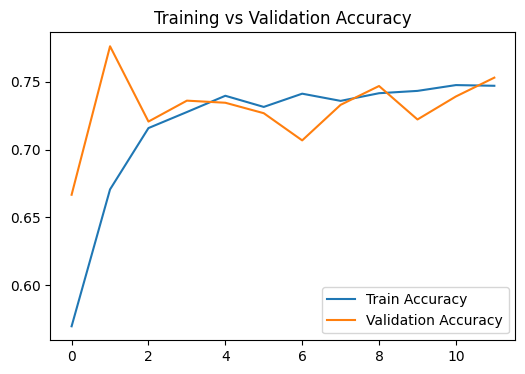

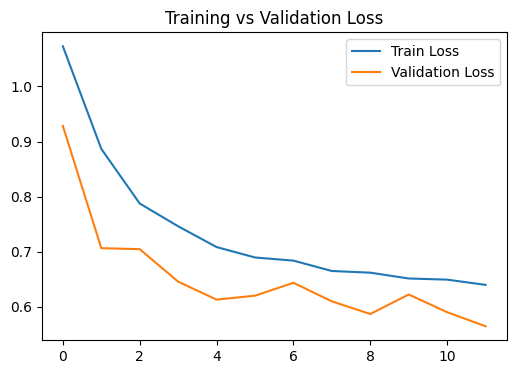

In [ ]:
# --- Step 11: Plot Accuracy and Loss ---
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

In [ ]:
####SBERT + BiLSTM + Attention + Focal Loss

In [ ]:
!pip install sentence-transformers tensorflow scikit-learn -q

import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf

from tensorflow.keras import layers, regularizers, backend as K

In [ ]:
!pip install --upgrade transformers tensorflow --quiet

In [ ]:

df = df.dropna(subset=["Reviews", "final_sentiment"]).reset_index(drop=True)

le = LabelEncoder()
df["label_id"] = le.fit_transform(df["final_sentiment"])

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["Reviews"], df["label_id"], test_size=0.2, random_state=42, stratify=df["label_id"]
)


In [ ]:
sbert = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')

print("Encoding text into SBERT embeddings (takes a few minutes)...")
X_train_emb = sbert.encode(X_train_text.tolist(), convert_to_numpy=True, show_progress_bar=True)
X_test_emb  = sbert.encode(X_test_text.tolist(), convert_to_numpy=True, show_progress_bar=True)

num_classes = len(le.classes_)
input_dim = X_train_emb.shape[1]

# reshape to (samples, timesteps, features)
X_train_seq = np.expand_dims(X_train_emb, axis=1)
X_test_seq  = np.expand_dims(X_test_emb, axis=1)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding text into SBERT embeddings (takes a few minutes)...


Batches:   0%|          | 0/203 [00:00<?, ?it/s]

Batches:   0%|          | 0/51 [00:00<?, ?it/s]

In [ ]:

def focal_loss(gamma=2., alpha=1.):
    def focal_loss_fixed(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, K.epsilon(), 1 - K.epsilon())
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.math.pow(1 - y_pred, gamma)
        return tf.reduce_mean(tf.reduce_sum(weight * cross_entropy, axis=1))
    return focal_loss_fixed


In [ ]:

class AttentionLayer(layers.Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1),
                                 initializer="random_normal", trainable=True)
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1),
                                 initializer="zeros", trainable=True)
        super(AttentionLayer, self).build(input_shape)

    def call(self, x):
        e = tf.keras.backend.tanh(tf.keras.backend.dot(x, self.W) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = x * a
        return tf.keras.backend.sum(output, axis=1)

In [ ]:
# STEP 6. BiLSTM + Attention Model
# ===============================
def build_bilstm_attention_model(input_dim, num_classes):
    inp = layers.Input(shape=(1, input_dim))
    x = layers.Bidirectional(layers.LSTM(256, return_sequences=True, dropout=0.3))(inp)
    x = AttentionLayer()(x)
    x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation="softmax")(x)
    model = tf.keras.Model(inputs=inp, outputs=out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=2e-4),
        loss=focal_loss(gamma=2.0, alpha=1.0),
        metrics=["accuracy"]
    )
    return model

model = build_bilstm_attention_model(input_dim, num_classes)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 1, 768)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 1, 512)         │     2,099,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer                 │ (None, 512)            │           513 │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,165,764 (8.26 MB)

 Trainable params: 2,165,764 (8.26 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ===============================
# STEP 7. Train the Model

y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes)
y_test_cat  = tf.keras.utils.to_categorical(y_test, num_classes)

history = model.fit(
    X_train_seq, y_train_cat,
    validation_data=(X_test_seq, y_test_cat),
    epochs=15,
    batch_size=16,
    verbose=1
)


Epoch 1/15
405/405 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.7293 - loss: 0.3388 - val_accuracy: 0.8235 - val_loss: 0.2212
Epoch 2/15
405/405 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8400 - loss: 0.2023 - val_accuracy: 0.8377 - val_loss: 0.2055
Epoch 3/15
405/405 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8270 - loss: 0.2073 - val_accuracy: 0.8364 - val_loss: 0.2054
Epoch 4/15
405/405 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8408 - loss: 0.1936 - val_accuracy: 0.8383 - val_loss: 0.1989
Epoch 5/15
405/405 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8306 - loss: 0.1934 - val_accuracy: 0.8426 - val_loss: 0.1964
Epoch 6/15
405/405 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8385 - loss: 0.1889 - val_accuracy: 0.8327 - val_loss: 0.1972
Epoch 7/15
405/405 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8433 - loss: 0.1858 - val_accuracy: 0.8401 - val_loss: 0.1988
Epoch 8/15
405/405 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8427 - loss: 0.1845 - val_accuracy:

In [ ]:
# STEP 8. Evaluation
# ===============================
y_pred = np.argmax(model.predict(X_test_seq), axis=1)
print("\nClassification Report (SBERT + BiLSTM + Attention + Focal Loss):")
print(classification_report(y_test, y_pred, target_names=le.classes_.tolist()))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

Classification Report (SBERT + BiLSTM + Attention + Focal Loss):
              precision    recall  f1-score   support

    Negative       0.85      0.89      0.87       735
     Neutral       0.45      0.13      0.20       143
    Positive       0.85      0.93      0.88       742

    accuracy                           0.84      1620
   macro avg       0.72      0.65      0.65      1620
weighted avg       0.81      0.84      0.82      1620

Confusion Matrix:
 [[653  17  65]
 [ 64  18  61]
 [ 49   5 688]]


In [ ]:
###(SBERT + BiLSTM + Attention + Focal Loss) model by:

####Adding a numeric sentiment intensity score (from VADER).

####Applying hybrid label smoothing, so the model doesn’t overfit sharp boundaries — especially helpful for Neutral.

In [ ]:
!pip install transformers datasets accelerate -q

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split # Import train_test_split here
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score
import torch

In [ ]:
# Encode labels (Negative=0, Neutral=1, Positive=2)
label_map = {"Negative": 0, "Neutral": 1, "Positive": 2}
df["label"] = df["final_sentiment"].map(label_map)

In [ ]:
 ##--- Step 3: Split train/test ---
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42)

In [ ]:
# --- Step 4: Load tokenizer & prepare datasets ---
model_name = "microsoft/deberta-v3-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def preprocess_function(examples):
    return tokenizer(examples["Reviews"], truncation=True, padding="max_length", max_length=256)

train_dataset = Dataset.from_pandas(train_df[["Reviews", "label"]])
test_dataset = Dataset.from_pandas(test_df[["Reviews", "label"]])

train_dataset = train_dataset.map(preprocess_function, batched=True)
test_dataset = test_dataset.map(preprocess_function, batched=True)

train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])


Map:   0%|          | 0/6480 [00:00<?, ? examples/s]

Map:   0%|          | 0/1620 [00:00<?, ? examples/s]

In [ ]:
# --- Step 5: Load DeBERTa model ---
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# --- Step 6: Define metrics ---
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='weighted')
    prec = precision_score(labels, preds, average='weighted')
    rec = recall_score(labels, preds, average='weighted')
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

In [ ]:
# --- Step 7: Training arguments ---
training_args = TrainingArguments(
    output_dir="./deberta_sentiment",
    eval_strategy="epoch", # Corrected argument name
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    report_to=['none'] # Explicitly set report_to to disable wandb logging
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

/tmp/ipython-input-1377821198.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"     # Disable W&B completely
os.environ["WANDB_MODE"] = "disabled"     # Extra safeguard
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "true"


In [ ]:

# --- Step 9: Train ---
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.337500,0.332612,0.901852,0.890996,0.901852,0.883749
2,0.240900,0.347527,0.903704,0.892391,0.903704,0.895701
3,0.153400,0.432995,0.909259,0.904244,0.909259,0.906377


TrainOutput(global_step=2430, training_loss=0.23465021058855723, metrics={'train_runtime': 719.8156, 'train_samples_per_second': 27.007, 'train_steps_per_second': 3.376, 'total_flos': 2557508285030400.0, 'train_loss': 0.23465021058855723, 'epoch': 3.0})

In [ ]:
# --- Step 10: Evaluate ---
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

print("\nClassification Report (DeBERTa-v3-base):")
print(classification_report(y_true, y_pred, target_names=["Negative", "Neutral", "Positive"]))


Classification Report (DeBERTa-v3-base):
              precision    recall  f1-score   support

    Negative       0.92      0.94      0.93       735
     Neutral       0.56      0.48      0.52       143
    Positive       0.95      0.96      0.95       742

    accuracy                           0.91      1620
   macro avg       0.81      0.79      0.80      1620
weighted avg       0.90      0.91      0.91      1620

